# **North Sea IBTS : GLMER models**

In [45]:
library(corrplot)
library(dplyr)
library(energy)
library(FactoMineR)
library(factoextra)
library(GGally)
library(ggplot2)
library(gsl)
library(infotheo)
library(lme4)
library(lmtest)
library(lubridate)
library(nlme)
library(patchwork)
library(purrr)
library(readr)
library(rprojroot)
library(Rtsne)
library(tidyr)
library(umap)
library(wesanderson)

### Set working directory

In [17]:
proj_root <- find_root(has_file(".git") | is_rstudio_project)
setwd(file.path(proj_root, "SR_Estimation", "stat_analysis_2026", "data"))

# Data exploration

## Individual data

### Data importation

In [18]:
table_cohortes <- read.csv("table_cohorte_procedure_selection_2.csv", 
                           header = TRUE, sep = ",",  na ="NA", stringsAsFactors = FALSE)
table_donnees <- read.csv("tableau_donnees_procedure_selection_2.csv", 
                          header = TRUE, sep = ",",  na ="NA", stringsAsFactors = FALSE)

### Visualize individual counts per cohort and species

#### Individual counts per species

In [19]:
table_donnees <- table_donnees %>%
  mutate(Survey = as.factor(Survey),
         Species = as.factor(Species),
         Sex = as.factor(Sex),
         Maturity = as.factor(Maturity))

In [20]:
nb_species <- table_donnees %>%
  count(Species)

Given the counts, **Microstomus kitt** and **Scomber scombrus** present
data scarcity.

Let us investigate the counting per species and cohort.

#### Histogram of the counts per species and cohort

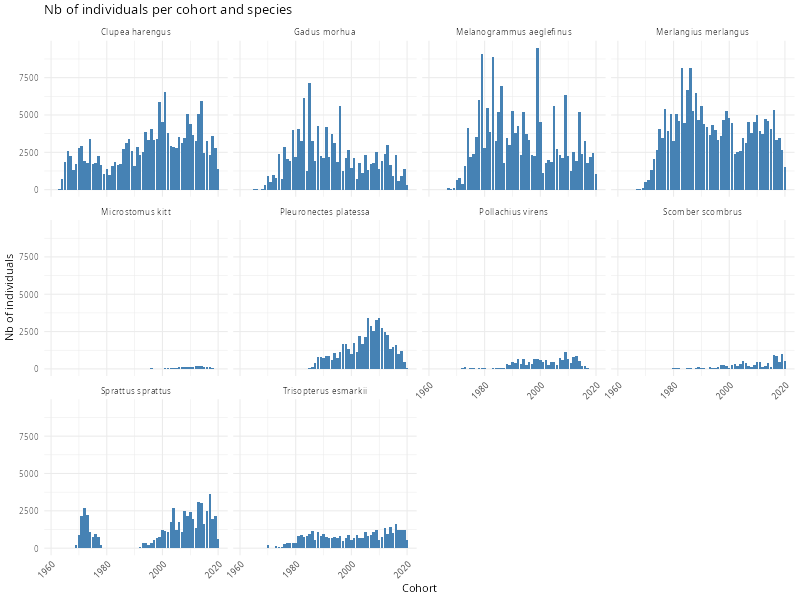

In [21]:
nb_species_by_cohorte <- table_donnees %>%
  count(Species, Cohorte) %>%
  complete(Species, Cohorte, fill = list(n = 0))

ggplot(nb_species_by_cohorte, aes(x = Cohorte, y = n)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  facet_wrap(~ Species, scales = "fixed") +
  ylim(0, max(nb_species_by_cohorte$n, na.rm = TRUE)) + 
  labs(
    title = "Nb of individuals per cohort and species",
    x = "Cohort",
    y = "Nb of individuals"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Visualize the length-age relationship

There were 50 or more warnings (use warnings() to see the first 50)


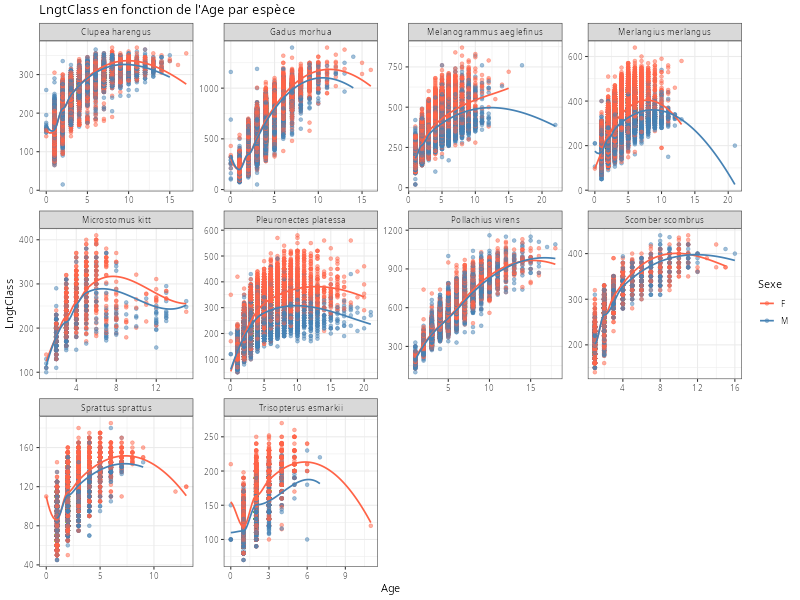

In [ ]:
ggplot(table_donnees %>% filter(Sex %in% c("M", "F")),
       aes(x = Age, y = LngtClass, color = Sex)) +
  geom_point(alpha = 0.5, size = 1.5) +
  scale_color_manual(values = c("M" = "steelblue", "F" = "tomato")) +
  facet_wrap(~ Species, scales = "free") +
  theme_bw() +
  geom_smooth(method = "loess", se = FALSE, linewidth = 0.8, formula = "y ~ x") +
  labs(title = "LngtClass en fonction de l'Age par espèce",
       x = "Age", y = "LngtClass", color = "Sexe")

_The use of the LOESS function implies warnings. Those can be ignored to get an idea of the global relationships_
It is clear that there is a _bias_ favoring the older individuals to be smaller.  
> This bias very much looks like a fishery-induced length selection

### Visualize the length-weigth relasionship

There were 50 or more warnings (use warnings() to see the first 50)


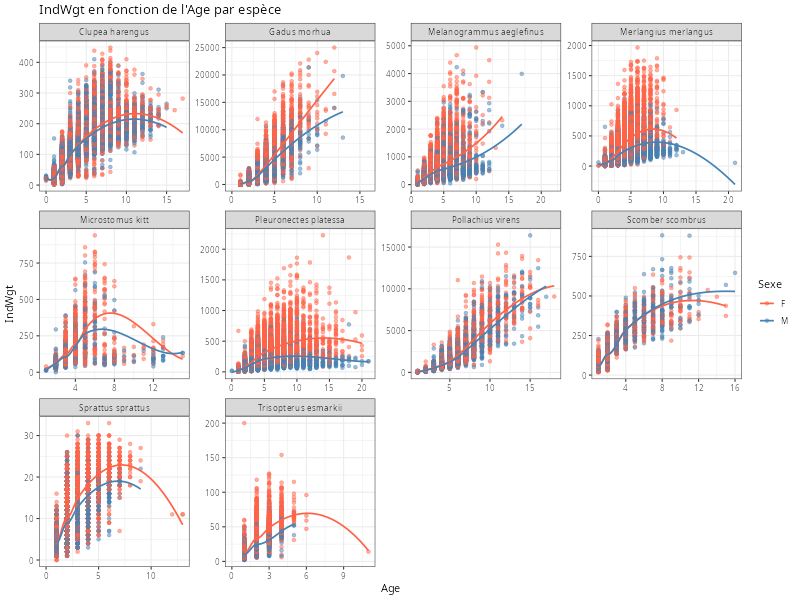

In [44]:
ggplot(table_donnees %>% filter(Sex %in% c("M", "F")),
       aes(x = Age, y = IndWgt, color = Sex)) +
  geom_point(alpha = 0.5, size = 1.5) +
  scale_color_manual(values = c("M" = "steelblue", "F" = "tomato")) +
  facet_wrap(~ Species, scales = "free") +
  theme_bw() +
  geom_smooth(method = "loess", se = FALSE, linewidth = 0.8, formula = "y ~ x") +
  labs(title = "IndWgt en fonction de l'Age par espèce",
       x = "Age", y = "IndWgt", color = "Sexe")

## Environmental data

### Data importation

**NAO data** :
<https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/nao_index.html>

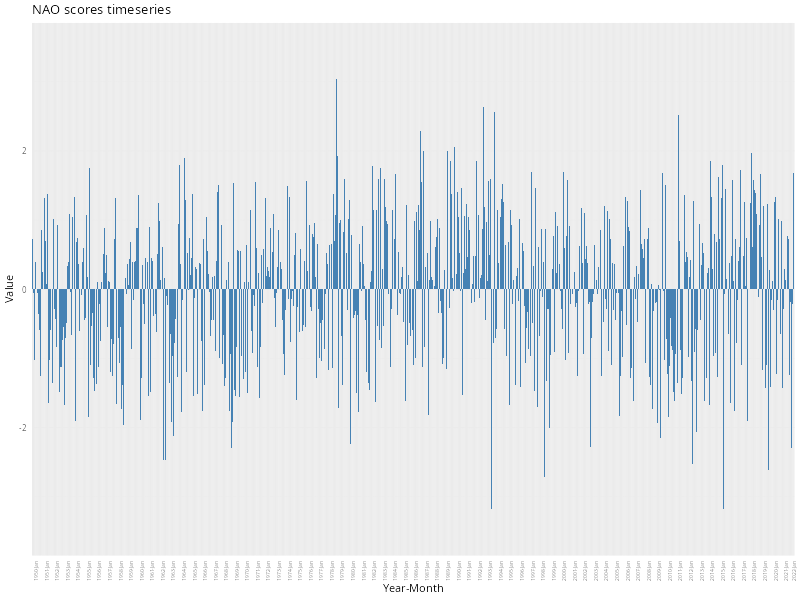

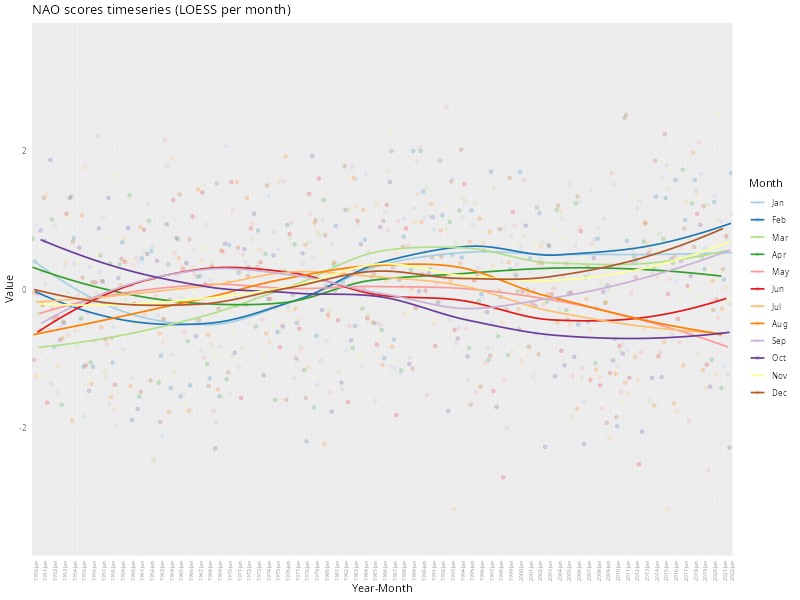

In [22]:
tableau_NAO <- read.csv("Monthly_mean_NAO_index_since_January_1950.csv", header = FALSE, sep = ";")

months_en <- c("Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec")

tableau_NAO <- tableau_NAO %>%
  rename(year = 1,  
    !!!setNames(2:13, months_en))

tableau_NAO_long <- tableau_NAO %>%
  pivot_longer(
    cols = Jan:Dec,          
    names_to = "Month",
    values_to = "Value") %>%
  mutate(
    Month = factor(Month, levels = c("Jan","Feb","Mar","Apr","May","Jun",
                                     "Jul","Aug","Sep","Oct","Nov","Dec"))) %>%
  mutate(YearMonth = paste(year, Month, sep = "-")) %>%
  filter(!is.na(Value))

ggplot(tableau_NAO_long, aes(x = YearMonth, y = Value)) +
  geom_col(fill = "steelblue") +
  labs(x = "Year-Month", y = "Value",
       title = "NAO scores timeseries") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5)) +
  scale_x_discrete(labels = function(x) {sapply(x, function(xx) {if(grepl("-Jan$", xx)) xx else ""})}) +
  coord_cartesian(ylim = c(-3.5, 3.5))

ggplot(tableau_NAO_long, aes(x = YearMonth, y = Value, color = Month)) +
  geom_point(alpha = 0.2, size = 1.5) +
  geom_smooth(aes(group = Month), method = "loess", se = FALSE, linewidth = 0.8, formula = 'y ~ x') +
  labs(x = "Year-Month", y = "Value",
       title = "NAO scores timeseries (LOESS per month)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5),
        legend.position = "right") +
  scale_x_discrete(labels = function(x) {sapply(x, function(xx) { if (grepl("-Jan$", xx)) xx else "" })}) + 
  scale_color_brewer(palette = "Paired") +
  coord_cartesian(ylim = c(-3.5, 3.5))

Other helpful resources can be found here :
<https://psl.noaa.gov/data/climateindices/>
<https://psl.noaa.gov/cgi-bin/data/climateindices/corr.pl?tstype1=3&custname1=&custtitle1=&tstype2=0&custname2=&custtitle2=&year1=&year2=&itypea=0&y1=&y2=&plotstyle=0&length=&lag=&iall=0&iseas=1&mon1=0&mon2=2&anom=0&climo1_yr1=&climo1_yr2=&climo2_yr1=&climo2_yr2=&Submit=Calculate+Results>

**AMO data** : <https://psl.noaa.gov/data/timeseries/AMO/>

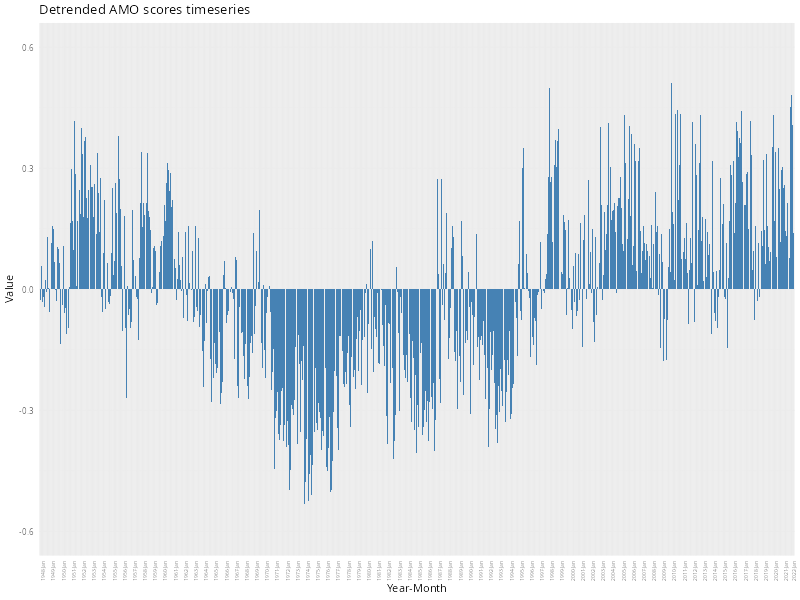

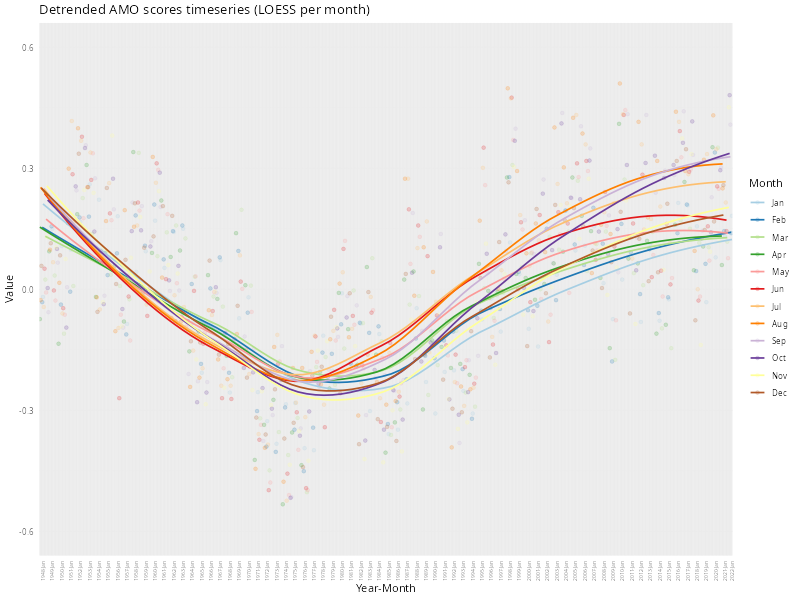

In [23]:
tableau_AMO <- read.csv("AMO_unsmoothed_detrended_from_the_Kaplan_SST_V2.csv", header = FALSE, sep = ";")

tableau_AMO <- tableau_AMO %>%
  mutate(across(everything(), as.numeric)) %>%
  mutate(across(everything(), ~na_if(., -99.990)))

months_en <- c("Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec")

tableau_AMO <- tableau_AMO %>%
  rename(year = 1,  
    !!!setNames(2:13, months_en))

tableau_AMO_long <- tableau_AMO %>%
  pivot_longer(
    cols = Jan:Dec,          
    names_to = "Month",
    values_to = "Value") %>%
  mutate(
    Month = factor(Month, levels = c("Jan","Feb","Mar","Apr","May","Jun",
                                     "Jul","Aug","Sep","Oct","Nov","Dec"))) %>%
  mutate(YearMonth = paste(year, Month, sep = "-")) %>%
  filter(!is.na(Value)) 

ggplot(tableau_AMO_long, aes(x = YearMonth, y = Value)) +
  geom_col(fill = "steelblue") +
  labs(x = "Year-Month", y = "Value",
       title = "Detrended AMO scores timeseries") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5)) +
  scale_x_discrete(labels = function(x) {sapply(x, function(xx) {if(grepl("-Jan$", xx)) xx else ""})}) +
  coord_cartesian(ylim = c(-0.6, 0.6))

ggplot(tableau_AMO_long, aes(x = YearMonth, y = Value, color = Month)) +
  geom_point(alpha = 0.2, size = 1.5) +
  geom_smooth(aes(group = Month), method = "loess", se = FALSE, linewidth = 0.8, formula = 'y ~ x') +
  labs(x = "Year-Month", y = "Value",
       title = "Detrended AMO scores timeseries (LOESS per month)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5),
        legend.position = "right") +
  scale_x_discrete(labels = function(x) {sapply(x, function(xx) { if (grepl("-Jan$", xx)) xx else "" })}) + 
  scale_color_brewer(palette = "Paired") +
  coord_cartesian(ylim = c(-0.6, 0.6))

**AMO data (non detrended one)**

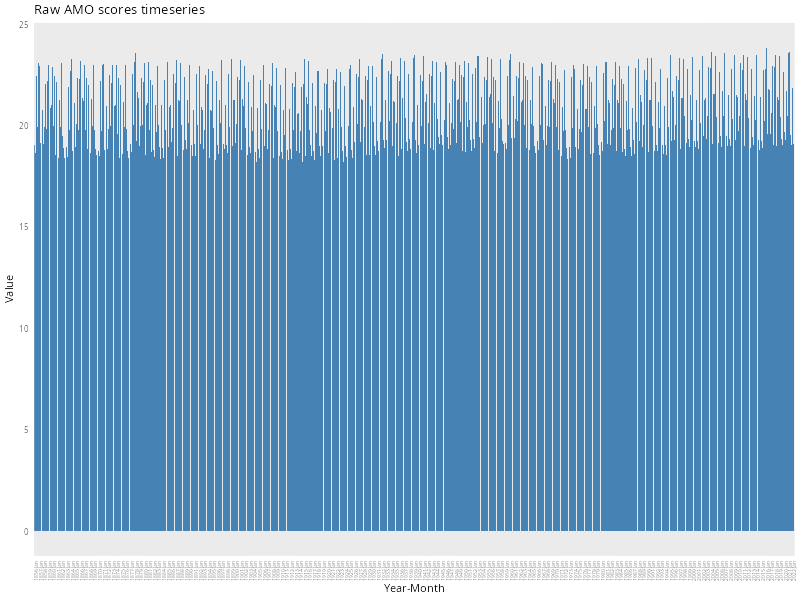

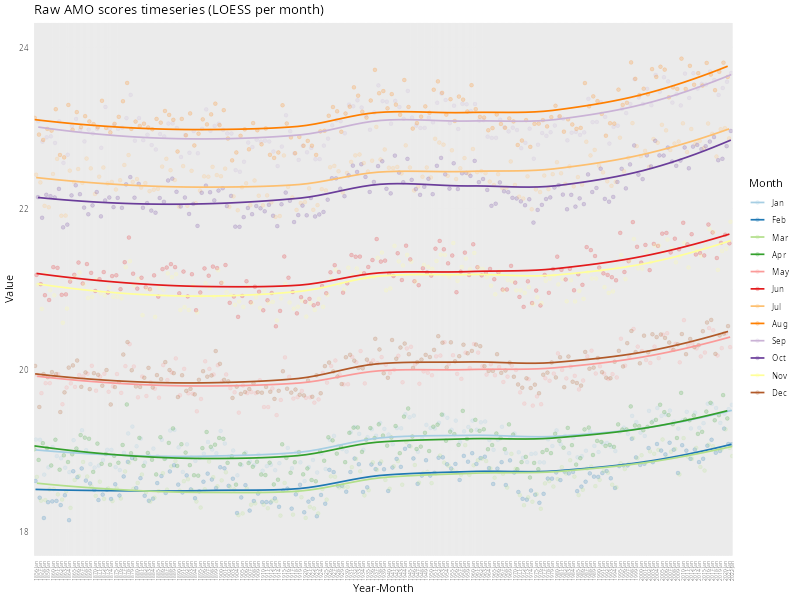

In [24]:
tableau_AMO_brute <- read.csv("AMO_non_detandence.csv", header = FALSE, sep = ";")

tableau_AMO_brute <- tableau_AMO_brute[1:(nrow(tableau_AMO_brute)-2), ]

tableau_AMO_brute <- tableau_AMO_brute %>%
  mutate(across(everything(), as.numeric)) %>%
  mutate(across(everything(), ~na_if(., -99.990)))

months_en <- c("Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec")

tableau_AMO_brute <- tableau_AMO_brute %>%
  rename(year = 1,  
    !!!setNames(2:13, months_en))

tableau_AMO_brute_long <- tableau_AMO_brute %>%
  pivot_longer(
    cols = Jan:Dec,          
    names_to = "Month",
    values_to = "Value") %>%
  mutate(
    Month = factor(Month, levels = c("Jan","Feb","Mar","Apr","May","Jun",
                                     "Jul","Aug","Sep","Oct","Nov","Dec"))) %>%
  mutate(YearMonth = paste(year, Month, sep = "-")) %>%
  filter(!is.na(Value))

ggplot(tableau_AMO_brute_long, aes(x = YearMonth, y = Value)) +
  geom_col(fill = "steelblue") +
  labs(x = "Year-Month", y = "Value",
       title = "Raw AMO scores timeseries") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5)) +
  scale_x_discrete(labels = function(x) {sapply(x, function(xx) {if(grepl("-Jan$", xx)) xx else ""})})

ggplot(tableau_AMO_brute_long, aes(x = YearMonth, y = Value, color = Month)) +
  geom_point(alpha = 0.2, size = 1.5) +
  geom_smooth(aes(group = Month), method = "loess", se = FALSE, linewidth = 0.8, formula = 'y ~ x') +
  labs(x = "Year-Month", y = "Value",
       title = "Raw AMO scores timeseries (LOESS per month)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5),
        legend.position = "right") +
  scale_x_discrete(labels = function(x) {sapply(x, function(xx) { if (grepl("-Jan$", xx)) xx else "" })}) + 
  scale_color_brewer(palette = "Paired") +
  coord_cartesian(ylim = c(18, 24))

**GSNW** <http://www.pml-gulfstream.org.uk/data.html>

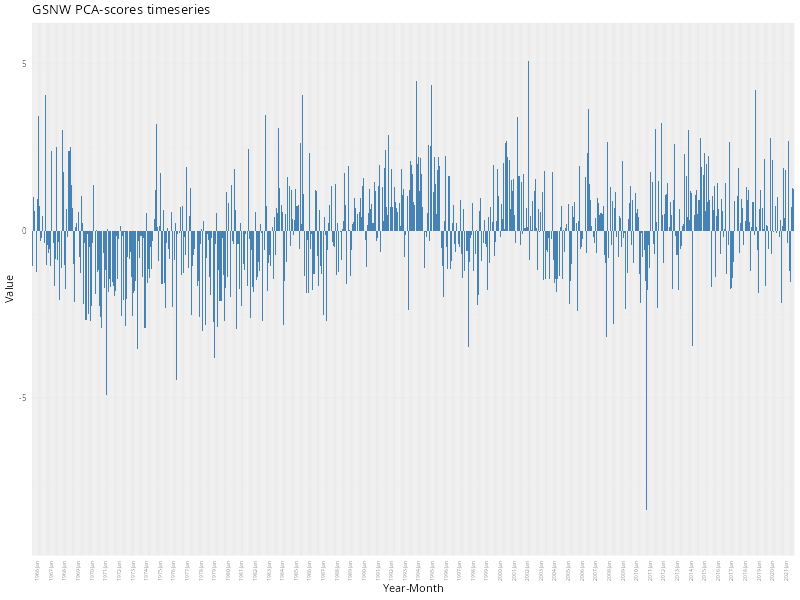

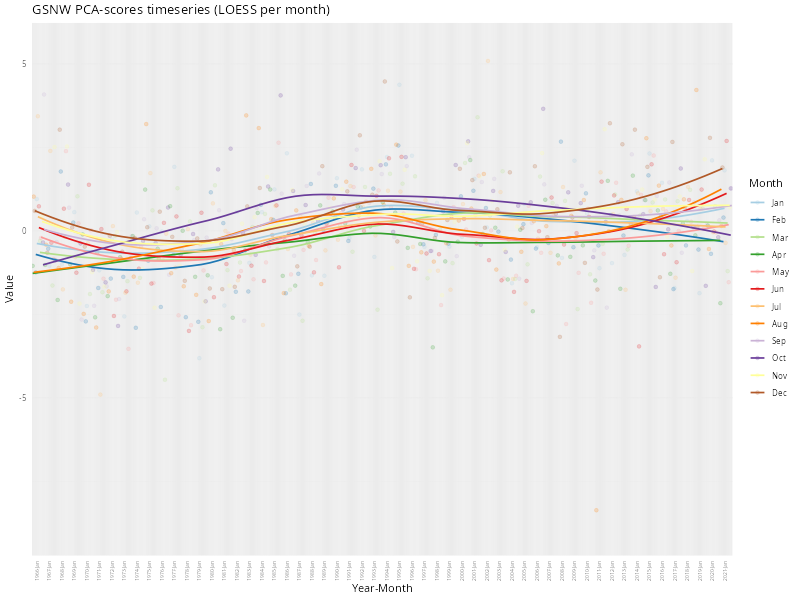

In [25]:
tableau_GSNW <- read.csv("GSNW_month.csv", header = TRUE, sep = ";")

# Supprimer la moyenne annuelle du tableau (recaculable au besoin)
tableau_GSNW <- tableau_GSNW[, -ncol(tableau_GSNW)]

tableau_GSNW_long <- tableau_GSNW %>%
  pivot_longer(
    cols = Jan:Dec,          
    names_to = "Month",
    values_to = "Value") %>%
  mutate(
    Month = factor(Month, levels = c("Jan","Feb","Mar","Apr","May","Jun",
                                     "Jul","Aug","Sep","Oct","Nov","Dec"))) %>%
  mutate(YearMonth = paste(year, Month, sep = "-")) %>%
  filter(!is.na(Value))

ggplot(tableau_GSNW_long, aes(x = YearMonth, y = Value)) +
  geom_col(fill = "steelblue") +
  labs(x = "Year-Month", y = "Value",
       title = "GSNW PCA-scores timeseries") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5)) +
  scale_x_discrete(labels = function(x) {sapply(x, function(xx) {if(grepl("-Jan$", xx)) xx else ""})}) +
  coord_cartesian(ylim = c(-9, 5.5))

ggplot(tableau_GSNW_long, aes(x = YearMonth, y = Value, color = Month)) +
  geom_point(alpha = 0.2, size = 1.5) +
  geom_smooth(aes(group = Month), method = "loess", se = FALSE, linewidth = 0.8, formula = 'y ~ x') +
  labs(x = "Year-Month", y = "Value",
       title = "GSNW PCA-scores timeseries (LOESS per month)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 5),
        legend.position = "right") +
  scale_x_discrete(labels = function(x) {sapply(x, function(xx) { if (grepl("-Jan$", xx)) xx else "" })}) +
  scale_color_brewer(palette = "Paired") +
  coord_cartesian(ylim = c(-9, 5.5))

### Understanding links between environmental variables

**Common dates across datasets**

First, we need to get a range of dates common to all environmental data sets.


In [27]:
get_range <- function(df, name){
  df %>%
    summarise(
      dataset = name,
      min_date = min(as.Date(paste(year, Month, "01"), "%Y %b %d")),
      max_date = max(as.Date(paste(year, Month, "01"), "%Y %b %d")))}

ranges <- bind_rows(
  get_range(tableau_AMO_long, "AMO"),
  get_range(tableau_AMO_brute_long, "AMO_brute"),
  get_range(tableau_GSNW_long, "GSNW"),
  get_range(tableau_NAO_long, "NAO"))

ranges

# A tibble: 4 × 3
  dataset   min_date   max_date  
  <chr>     <date>     <date>    
1 AMO       1948-01-01 2022-02-01
2 AMO_brute 1856-01-01 2022-03-01
3 GSNW      1966-01-01 2021-12-01
4 NAO       1950-01-01 2022-02-01

In [28]:
start_date <- max(ranges$min_date)
end_date   <- min(ranges$max_date)

start_date
end_date

[1] "2021-12-01"

Thus, the following pipeline will be calculated for dates between `1966-01-01` and `2021-12-01`.

Then we can filter data for the previous dates.

In [29]:
filter_range <- function(df){
  df %>%
    mutate(Date = as.Date(paste(year, Month, "01"), "%Y %b %d")) %>%
    filter(Date >= start_date & Date <= end_date)
}

amo   <- filter_range(tableau_AMO_long)
amo_b <- filter_range(tableau_AMO_brute_long)
gsnw  <- filter_range(tableau_GSNW_long)
nao   <- filter_range(tableau_NAO_long)

Finally, we join the data in a single dataset

In [30]:
amo <- amo %>% select(Date, AMO = Value)
amo_b <- amo_b %>% select(Date, AMO_brute = Value)
gsnw <- gsnw %>% select(Date, GSNW = Value)
nao <- nao %>% select(Date, NAO = Value)

data_all <- reduce(list(amo, amo_b, gsnw, nao), full_join, by="Date")

**Pipeline to find the common information between environmental variables**

First we scale the data

In [31]:
data_scaled <- scale(data_all %>% select(-Date), center = TRUE, scale = TRUE)

**Pearson correlation**

The Pearson correlation coefficient measures the **linear relationship**
between two continuous variables. It ranges from -1 to 1:

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$ where : - $r$ : Pearson correlation coefficient  
- $x_i, y_i$ : individual observations of variables X and Y  
- $\bar{x}, \bar{y}$ : mean of X and Y  
- $n$ : number of observations  


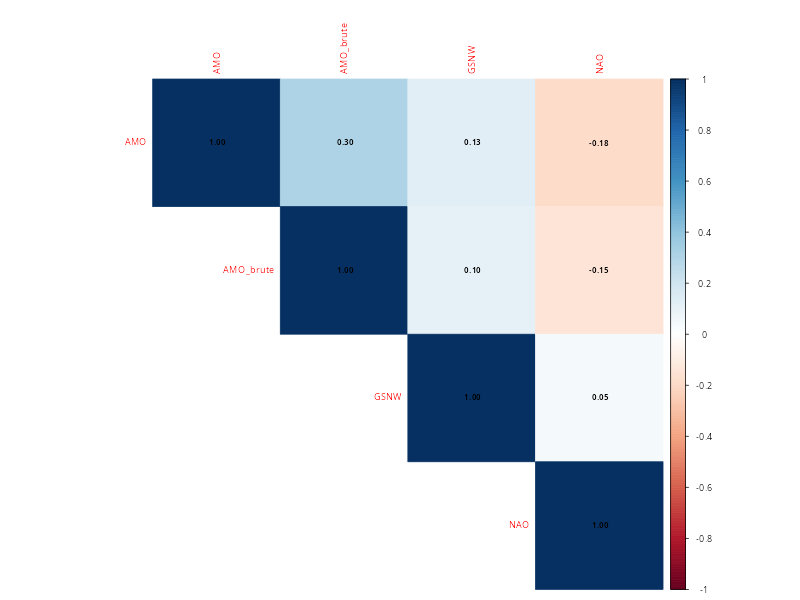

In [32]:
cor_pearson <- cor(data_scaled, method = "pearson")

cor_pearson

corrplot(
  cor_pearson,
  method = "color",
  type = "upper",
  addCoef.col = "black",
  number.cex = 0.7,
  tl.cex = 0.8)

**Spearman correlation**

Calculation of the Spearman correlation. Pearson correlation should not be used first as it only detects linear relationship between variables.

$$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$ where:\
- $\rho$ : Spearman correlation coefficient  
- $d_i$ : difference between the ranks of the two variables for observation $i$  
- $n$ : number of observations  

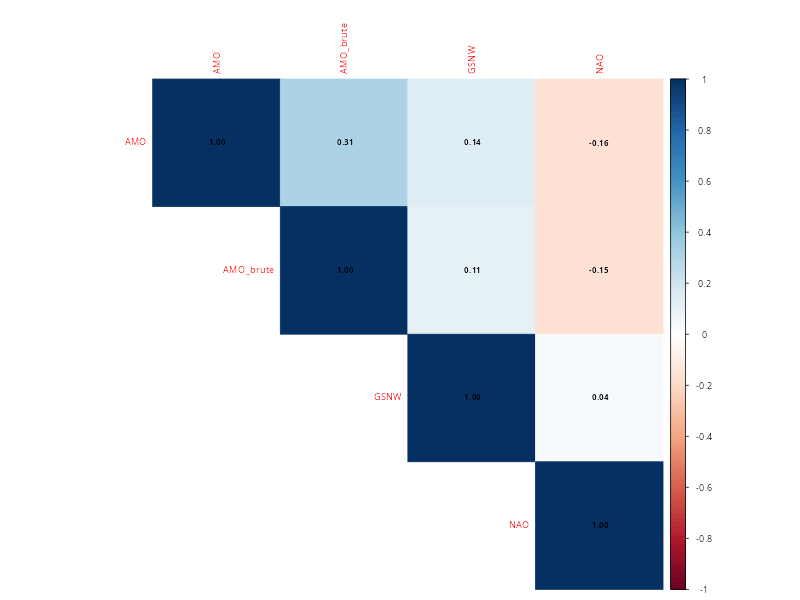

In [33]:
cor_spearman <- cor(data_scaled, method = "spearman")

cor_spearman

corrplot(
  cor_spearman,
  method = "color",
  type = "upper",
  addCoef.col = "black",
  number.cex = 0.7,
  tl.cex = 0.8)

**Pairwise plots of the data**

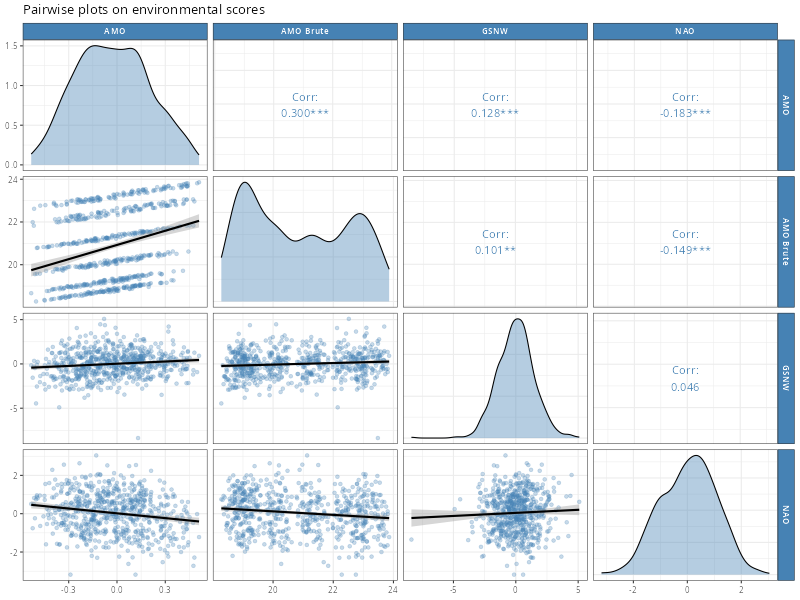

In [34]:
ggpairs(
  data_all %>% select(AMO, AMO_brute, GSNW, NAO),
  progress = FALSE,
  upper = list(
    continuous = wrap("cor", method = "pearson", size = 4, color = "steelblue")
  ),
  
  lower = list(
    continuous = wrap("smooth", alpha = 0.3, color = "steelblue", se = TRUE)
  ),
  
  diag = list(
    continuous = wrap("densityDiag", fill = "steelblue", alpha = 0.4)
  ),
  
  columnLabels = c("AMO", "AMO Brute", "GSNW", "NAO")
) +
  theme_bw() +
  labs(title = "Pairwise plots on environmental scores") +
  theme(
    strip.background = element_rect(fill = "steelblue"),
    strip.text = element_text(color = "white", face = "bold")
  )

**Linear relationships between the environmental variables**

We computed both Pearson and Spearman correlation matrices and pairwize
plots for the four environmental indices `AMO`, `AMO_brute`, `GSNW`,
`NAO` :

-   Pearson and Spearman correlations are very similar, indicating that
    the relationships between the variables are **linear**. This
    hypothesis is verified on the pairwize plots.\
-   Most correlations are moderate or weak, with some negative
    associations (e.g., AMO ↔ NAO).\
-   No strong non-linear monotone relationships are detected.

Since the variables are linearly correlated, **Principal Component Analysis (PCA)** is appropriate to explore the main patterns and reduce dimensionality while preserving linear variance.  

> These investigations support the use of PCA to understand the joint variance of the environmental scores

**PCA**

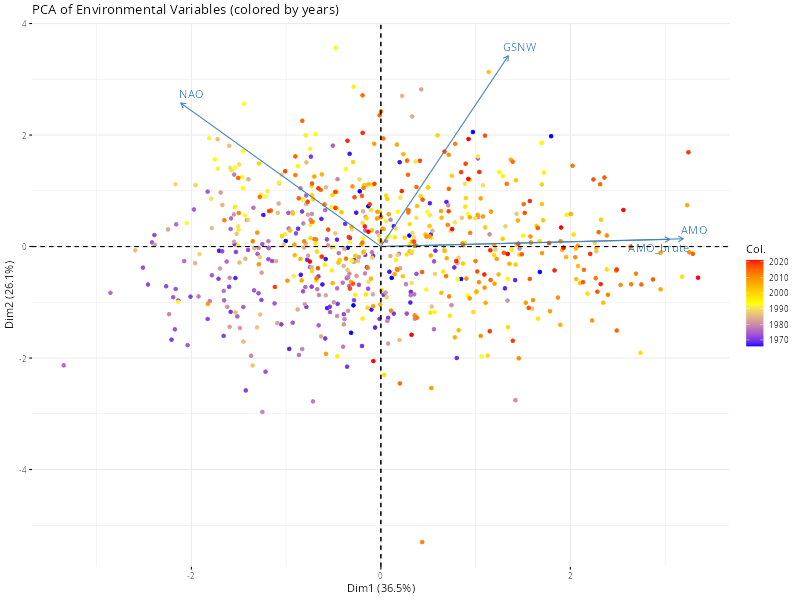

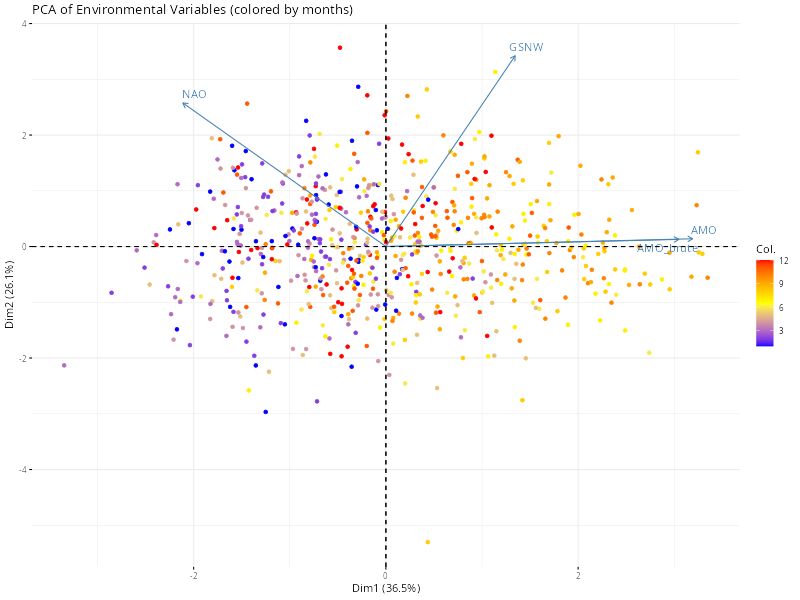

In [35]:
pca <- PCA(data_scaled, graph=FALSE)

years <- as.numeric(format(data_all$Date, "%Y"))
fviz_pca_biplot(
  pca,
  label = "var",
  geom.ind = "point",
  col.ind = years,
  gradient.cols = c("blue", "yellow", "red"),
  repel = TRUE,
  pointsize = 1.5,
  title = "PCA of Environmental Variables (colored by years)"
)


months_numeric <- as.numeric(format(data_all$Date, "%m"))
fviz_pca_biplot(
  pca,
  label = "var",            
  geom.ind = "point",       
  col.ind = months_numeric, 
  gradient.cols = c("blue", "yellow", "red"), 
  repel = TRUE,
  pointsize = 1.5,
  title = "PCA of Environmental Variables (colored by months)"
)

**UMAP**

Uniform Manifold Approximation and Projection (UMAP). It is a non-linear dimensionality reduction technique. It is used to **visualize** (and only visualize) the structure of high-dimensional data.

UMAP projector preserves the local structure of the data. Thus, observations that are close in the original space tend to remain close in the projected space.

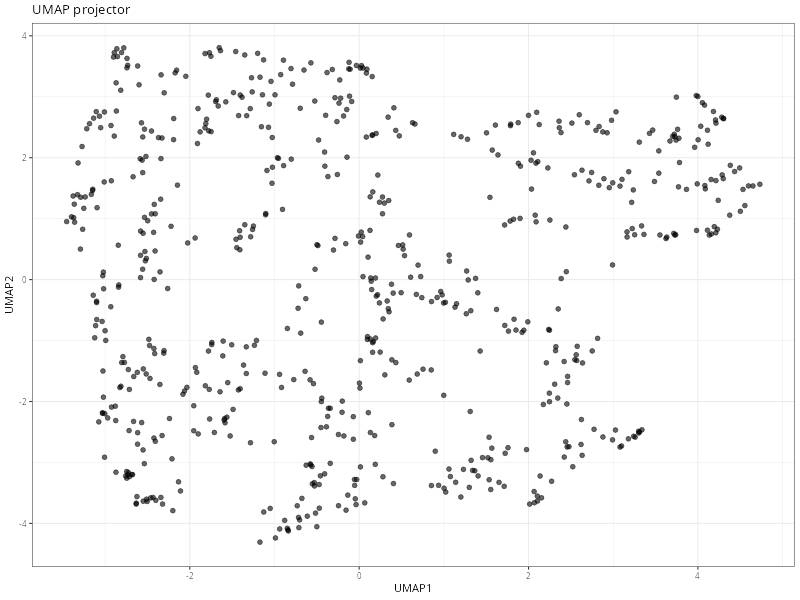

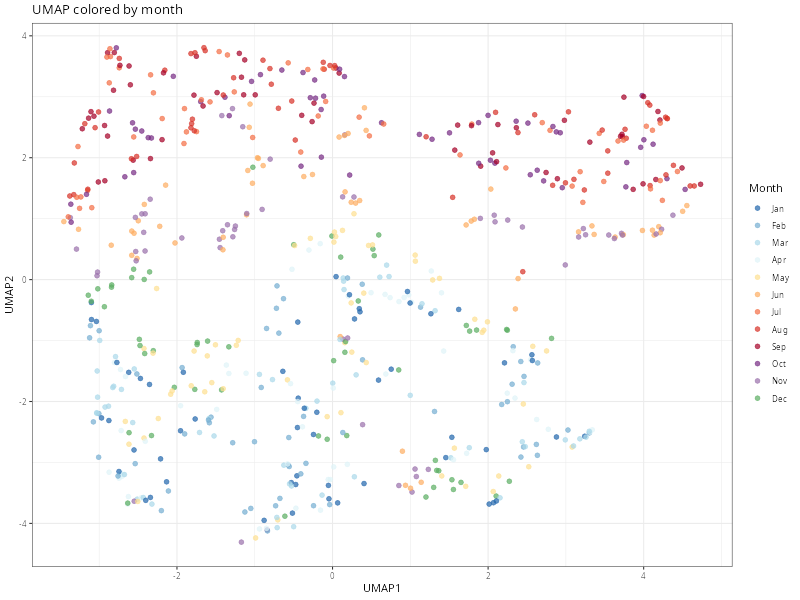

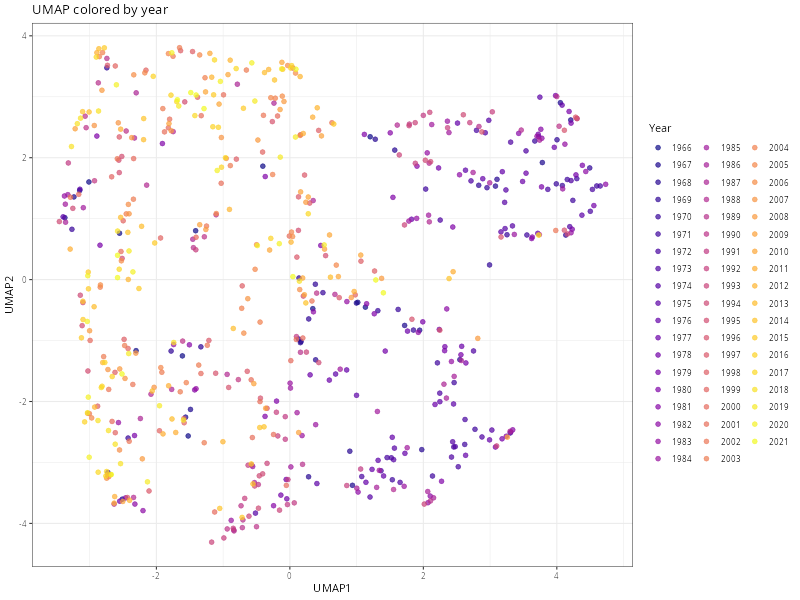

In [36]:
umap_res <- umap(data_scaled)

# Extraire mois et années depuis la colonne Date
umap_df <- data.frame(
  UMAP1 = umap_res$layout[, 1],
  UMAP2 = umap_res$layout[, 2],
  Mois  = factor(month(data_all$Date), levels = 1:12,
                 labels = c("Jan","Feb","Mar","Apr","May","Jun",
                            "Jul","Aug","Sep","Oct","Nov","Dec")),
  Année = factor(year(data_all$Date))
)

# --- Plot simple ---
ggplot(umap_df, aes(x = UMAP1, y = UMAP2)) +
  geom_point(alpha = 0.6, size = 2, color = "black") +
  theme_bw() +
  labs(title = "UMAP projector",
       x = "UMAP1", y = "UMAP2")

# --- Plot par MOIS ---
p_mois_umap <- ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = Mois)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_manual(values = colorRampPalette(
    c("#2166ac","#74add1","#abd9e9","#e0f3f8",
      "#fee090","#fdae61","#f46d43","#d73027",
      "#a50026","#762a83","#9970ab","#5aae61"))(12)) +
  theme_bw() +
  labs(title = "UMAP colored by month", color = "Month")

# --- Plot par ANNÉE ---
p_annee_umap <- ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = Année)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_viridis_d(option = "plasma") +
  theme_bw() +
  labs(title = "UMAP colored by year", color = "Year")

# ---- Affichage ----
p_mois_umap
p_annee_umap

**t_SNE**

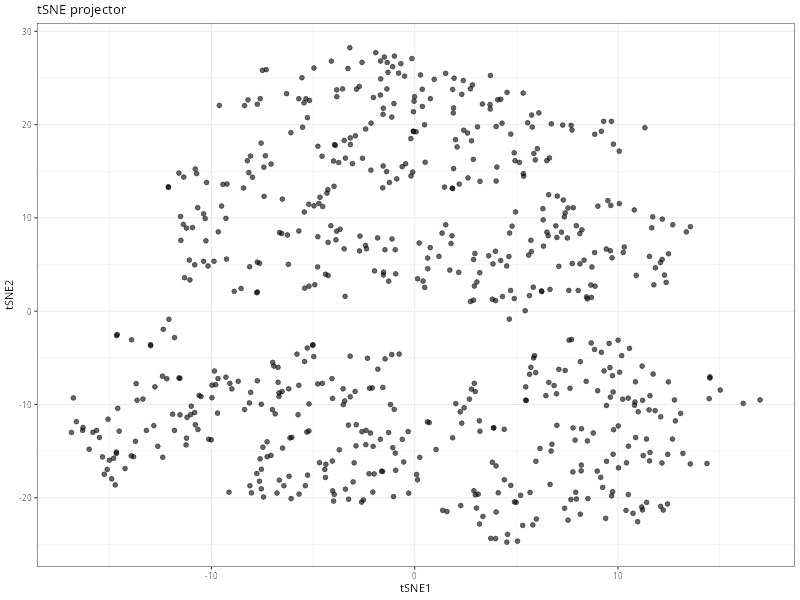

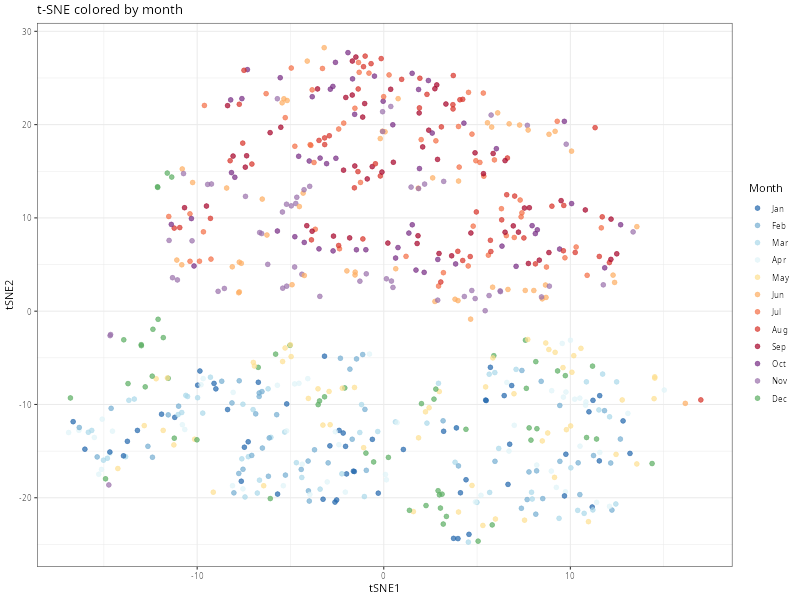

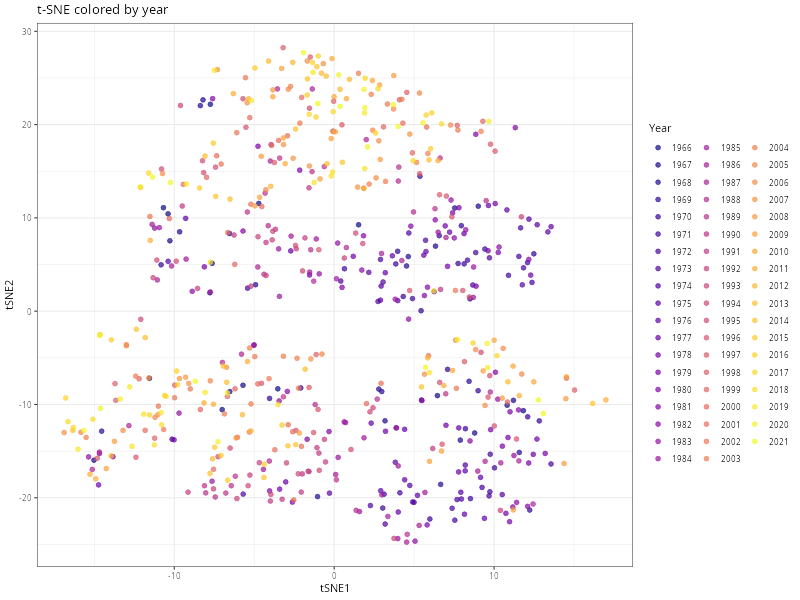

In [37]:
# --- t-SNE ---
set.seed(42)
tsne_res <- Rtsne(data_scaled, 
                  perplexity = 30,  
                  initial_dims = 4,
                  max_iter = 1000,
                  verbose = FALSE)

tsne_df <- data.frame(
  tSNE1 = tsne_res$Y[, 1],
  tSNE2 = tsne_res$Y[, 2],
  Mois  = factor(month(data_all$Date), levels = 1:12,
                 labels = c("Jan","Feb","Mar","Apr","May","Jun",
                            "Jul","Aug","Sep","Oct","Nov","Dec")),
  Année = factor(year(data_all$Date))
)

# --- Plot simple ---
ggplot(tsne_df, aes(x = tSNE1, y = tSNE2)) +
  geom_point(alpha = 0.6, size = 2, color = "black") +
  theme_bw() +
  labs(title = "tSNE projector",
       x = "tSNE1", y = "tSNE2")

# --- Plot par MOIS ---
p_mois_tsne <- ggplot(tsne_df, aes(x = tSNE1, y = tSNE2, color = Mois)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_manual(values = colorRampPalette(
    c("#2166ac","#74add1","#abd9e9","#e0f3f8",
      "#fee090","#fdae61","#f46d43","#d73027",
      "#a50026","#762a83","#9970ab","#5aae61"))(12)) +
  theme_bw() +
  labs(title = "t-SNE colored by month", color = "Month")

# --- Plot par ANNÉE ---
p_annee_tsne <- ggplot(tsne_df, aes(x = tSNE1, y = tSNE2, color = Année)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_viridis_d(option = "plasma") +
  theme_bw() +
  labs(title = "t-SNE colored by year", color = "Year")

# ---- Affichage ----
p_mois_tsne
p_annee_tsne